<center><strong>Pemrosesan Bahasa Natural</strong><br />
<strong><font color="blue">Rekayasa Kecerdasan Artifisial</font></strong><br />
</center>

<strong>Outline pertemuan minggu ke-5</strong><br />
<li> Pendahuluan Klasifikasi </li>
<li> K-NN, Naive Byaes, Decision Tree, SVM </li>
<li> Visualisasi dengan boxplot </li>


<p><img alt="" src="figures/56_Supervised VS unsupervised.png" style="height:500px; width:1153px" /></p>

### K-Nearest Neighbour (K-NN)
- Classifier yang paling sederhana
- Dapat digunakan untuk permaslaahn klasifikasi dan regresi

<strong> Kelebihan: </strong>
- Efisien untuk data berukuran besar
- Sederhana, mudah diimplementasikan
- Mudah dimodikasi (perhitungan jarak)
- Menangani data multiclass dengan mudah

<strong> Kekurangan: </strong>
- Semakin besar data semakin lambat performanya (menghitung NN)
- Memerlukan jumlah K optimal
- Tidak cocok untuk imbalance data

<p><img alt="" src="figures/6_kNN.JPG" style="height:300px; width:711px" /></p>

In [2]:
# load data pickle dari 20newsgroups yang didapat dari pertemuan 4
import pickle
import os

src_name = "20newsgroup.pckl"
src_path = os.path.join(src_name)
with open(src_path, 'rb') as fin:
    data = pickle.load(fin)

docs = [doc for doc in data.data]
label = data.target

print('DONE!')

DONE!


In [4]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
# preprocessing
import re
from nltk import sent_tokenize
from nltk import word_tokenize

def preprocess(doc):
    sents = sent_tokenize(doc)
    sents_tok = list() # tokenisasi kalimat
    for s in sents:
        s = s.strip().lower() # case folding dan menghilangkan new line
        s = s.replace("\n", " ") # menggantikan \n dengan spasi
        s = re.sub(r'[^a-zA-Z0-9 ]', ' ', s) # menghapus simbol
        s = re.sub(' +', ' ', s) # menghapus repetitive space

        sents_tok.append(s)

    return " ".join(sents_tok)

docs_clear = list()
for d in docs:
    docs_clear.append(preprocess(d))

In [6]:
# representasi vektor dengan VSM-TFIDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2)
X = tfidf_vectorizer.fit_transform(docs_clear)
print(X.shape)

(1653, 10721)


In [7]:
print(len(label))
print(len(docs_clear))
print(len(X.getnnz(1)))
print(X.shape)

1653
1653
1653
(1653, 10721)


In [8]:
# Cleaning noise
# Hapus label yang memiliki row = 0 pada tfidf-nya
# Hapus row yang memiliki nilai 0
Y = label[X.getnnz(1)>0]
X_clear = X[X.getnnz(1)>0]

# Hapus dokumen yang memiliki nilai row 0
docs_nonzero = list()
for i, d in enumerate(X.getnnz(1)>0):
    if d:
        docs_nonzero.append(docs_clear[i])

print(X_clear.shape, len(Y), len(docs_nonzero))

(1590, 10721) 1590 1590


In [9]:
# Membagi data menjadi dua yaitu data training dan data testing
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X_clear, Y, test_size=.3, random_state=8989)
print(X_train.shape, X_test.shape)

(1113, 10721) (477, 10721)


In [26]:
# KNN menggunakan scikit-learn library
# http://scikit-learn.org/stable/modules/neighbors.html
from sklearn import neighbors

n_neighbors = 8
weights = 'distance'
kNN = neighbors.KNeighborsClassifier(n_neighbors, weights=weights)
kNN.fit(X_train, Y_train)
print('Done!')

Done!


In [27]:
# Prediksi dengan KNN
Y_knn = kNN.predict(X_test)

In [28]:
# Evaluasi dengan akurasi
from sklearn.metrics import accuracy_score

accuracy_score(Y_test, Y_knn)

0.7568134171907757

<h3 id="Latihan:"><font color="blue">Latihan 1:</font></h3>

<ul>
    <li> Mengapa perlu dilakukan data splitting (training dan testing)?</li>
    <li> Apakah rasio splitting berpengaruh pada performa dari model? </li>
    <li> Cobalah beberapa model dengan merubah nilai dari parameter K, berapakah nilai K yang paling optimal? </li>

Jawaan:

1) Sebagai indikator untuk overfit juga, karena jika 100% data dipakai untuk training semua kita tidak tau apakah model-nya overfit atau tidak. Dikhawatirkan model hanya paham data yang dia pelajari saja, sedangkan di luar data yang dia pelajari performanya turun drastis.

2) Ya, rasio splitting juga berpengaruh ke model nya. Apabila data train jauh lebih kecil daripada data test, model bisa beresiko underfit atau tidak mempelajari datanya sama sekali atau minim informasi pelatihan. Sedangkan kalau data test yang jauh lebih kecil, model dikhawatirkan bisa overfit karena kurangnya data pengujian di luar data yang dipelajari model.

3) Berikut adalah tabel hasil percobaan beberapa nilai K:

    |K |Accuracy|
    |--|--------|
    |2 |0.83228 |
    |4 |0.82180 |
    |6 |0.79245 |
    |8 |0.75681 |
    |10|0.72746 |

### Naive Bayes Classifier

Metode klasifikasi dengan pendekatan probabilitas yang didasarkan pada teorema <strong>Bayes</strong>. Berasumsi bahwa semua fitur adalah independen dan memiliki kontribusi yang sama.

<p><img alt="" src="figures/naive_bayes.png" style="width: 400px ; height: 220px" /></p>

<strong>Dimana:</strong>
- x : fitur
- c : kelas
- P(c|x) : Probabilitas kelas c diberikan x sebagai fitur

<strong> Kelebihan:</strong>
- Cepat dan mudah diimplementasikan
- Cocok untuk multiclass
- Dapat bekerja dengan baik untuk data berdimensi tinggi (high-dimensional data)

<strong> Kekurangan:</strong>
- Asumsi bahwa semua fitur independen terkadang tidak sesuai dengan real-life data

In [29]:
# Menggunakan data sebelumnya
# Naive bayes menggunakan library scikit-learn
# http://scikit-learn.org/stable/modules/naive_bayes.html
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
nbc = gnb.fit(X_train.toarray(), Y_train)
Y_nbc = nbc.predict(X_test.toarray())

accuracy_score(Y_test, Y_nbc)

0.870020964360587

### Decision Tree

Decision tree menggunakan rule-based (if else condition) pada sebuah tree untuk membangan sebuah model. Decision tree dapat dipergunakan untuk categorical ataupun numerical data.

<p><img alt="" src="figures/6_DT.png" style="height:336px; width:904px" /></p>

<p> Contoh: </p>
<p><img alt="" src="figures/6_DT_meme.png" style="height:342px; width:460px" /></p>

<strong>Kelebihan:</strong>
- Mudah untuk dipahami, cocok untuk visualisasi
- Dapat digunakan untuk categorical maupun numerical data
- non-parametric model
- Robust terhadap outliers dan missing values

<strong>Kekurangan:</strong>
- Sering overfit





In [30]:
# Decision Tree dengan library scikit-learn
#http://scikit-learn.org/stable/modules/tree.html
from sklearn import tree

DT = tree.DecisionTreeClassifier()
DT = DT.fit(X_train, Y_train)
Y_DT = DT.predict(X_test)

accuracy_score(Y_test, Y_DT)

0.6645702306079665

In [31]:
!pip install pydotplus

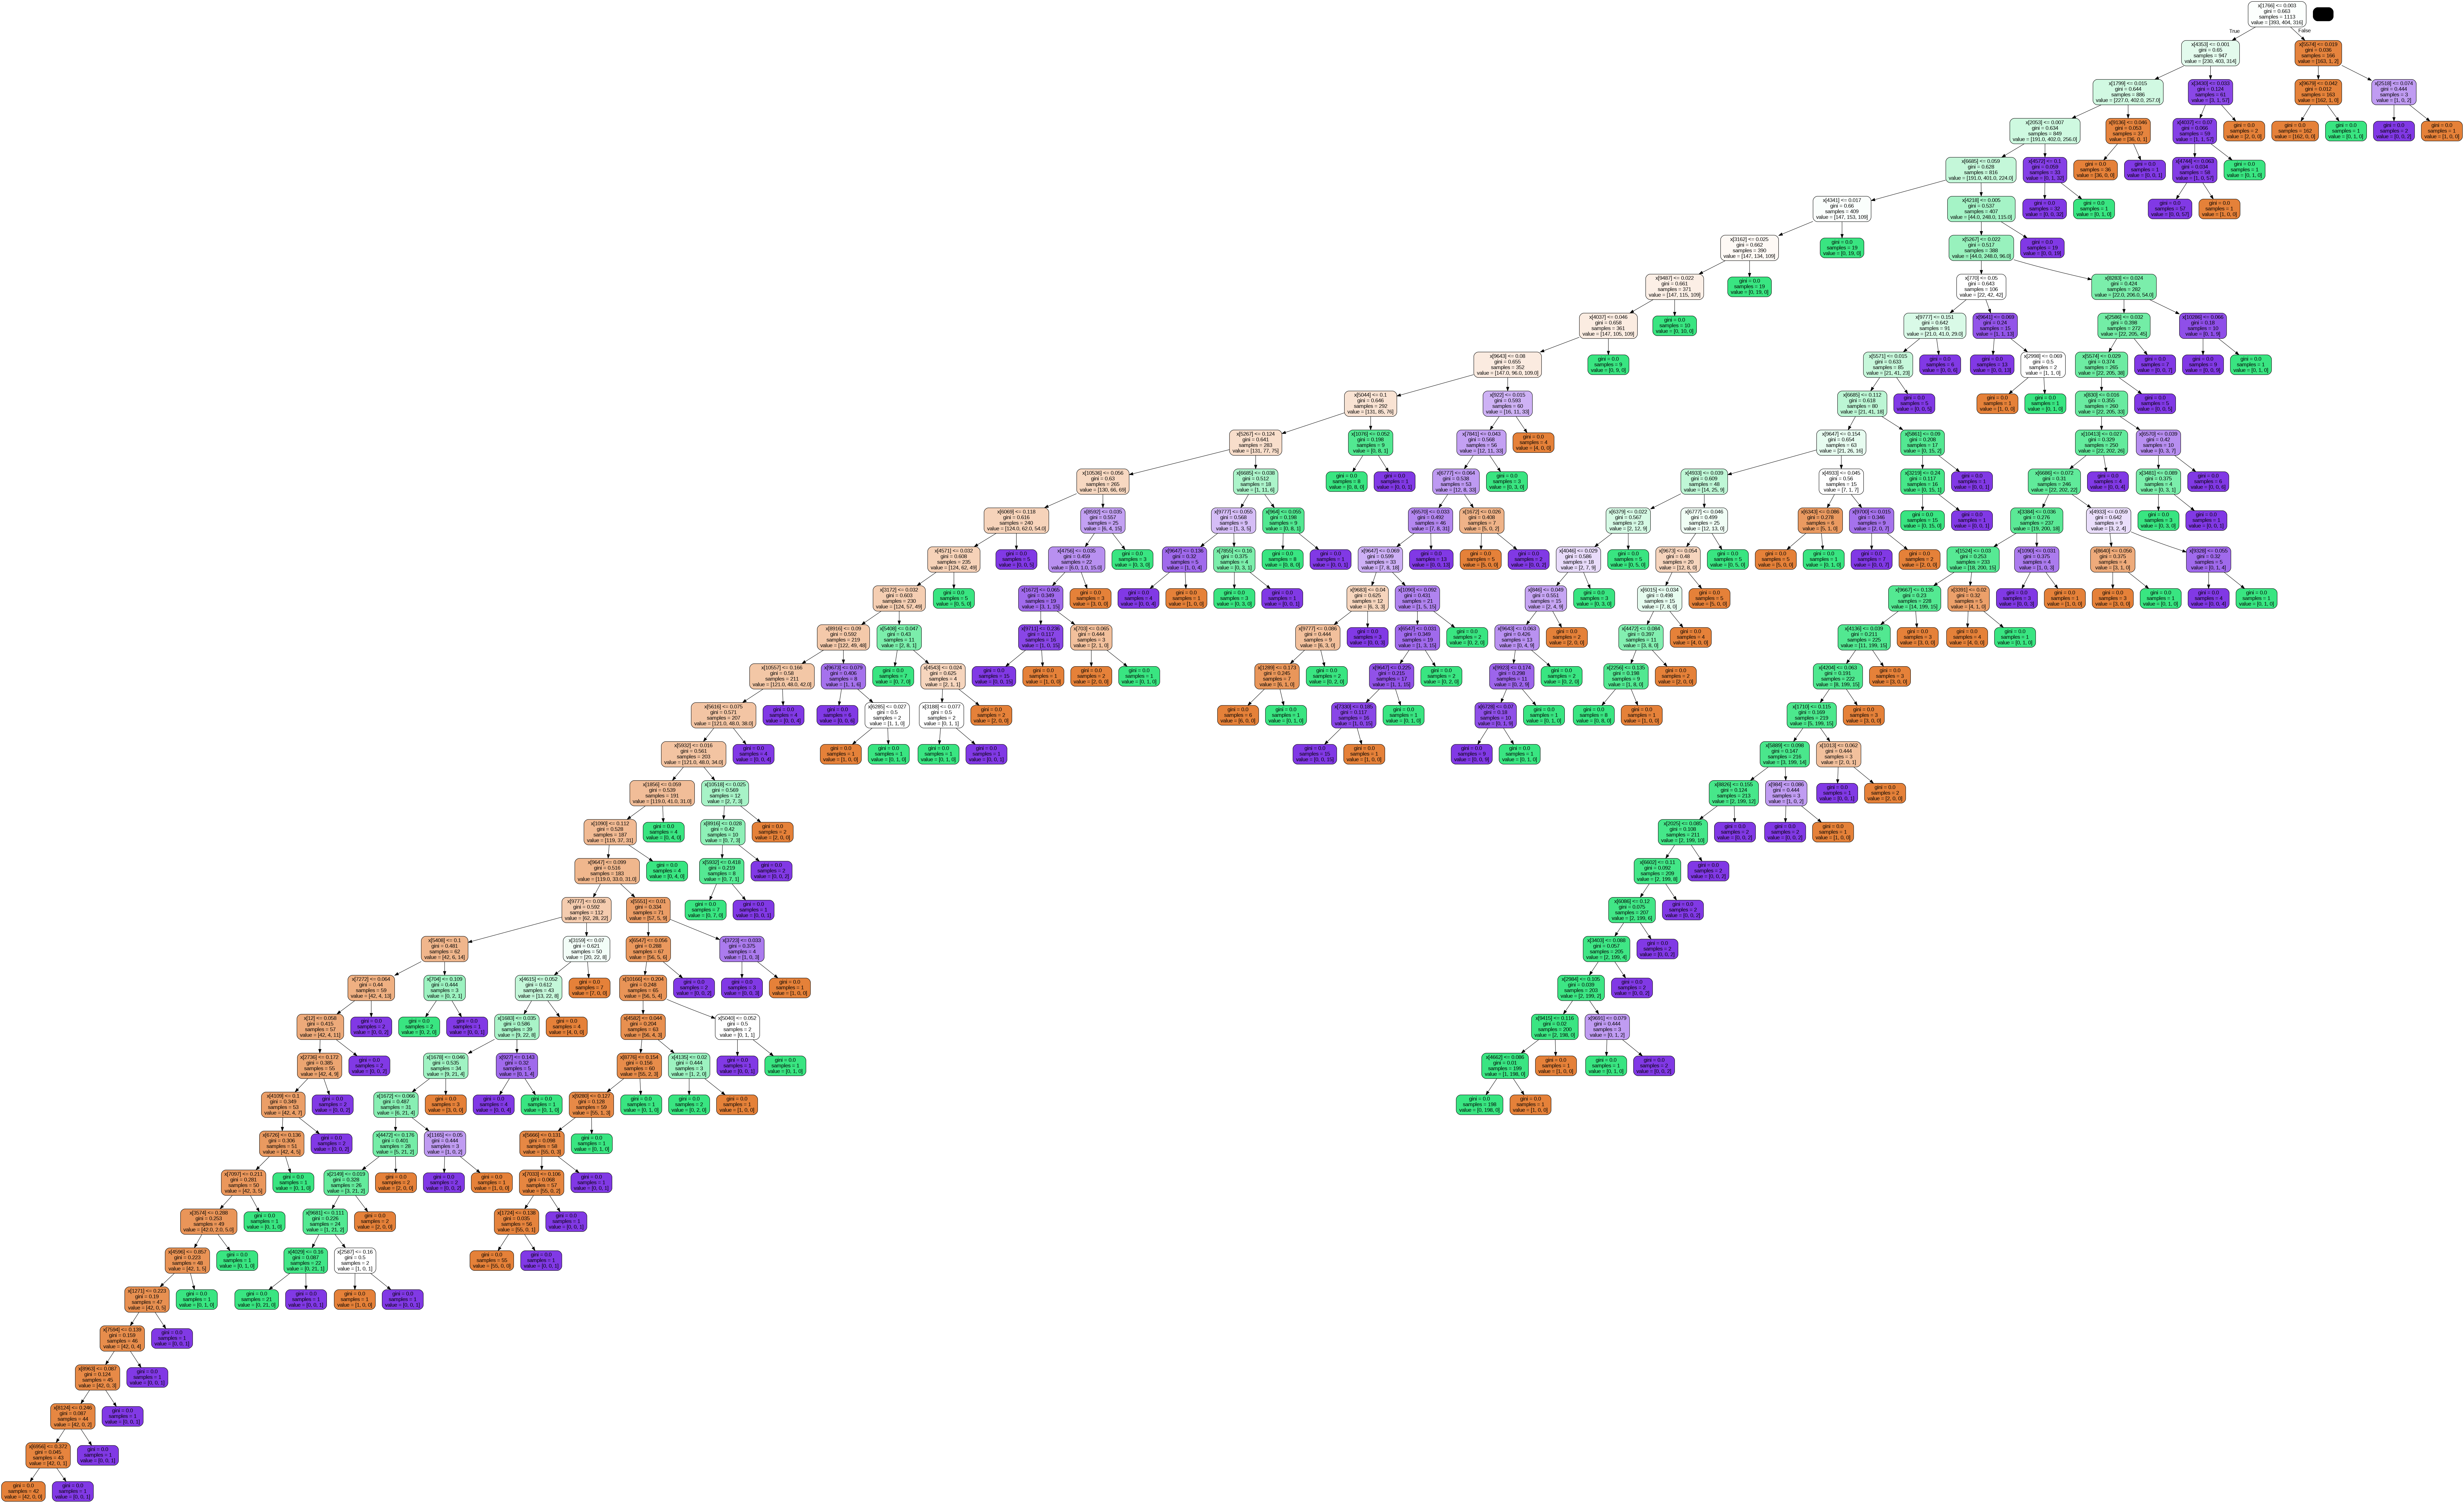

In [33]:
# Visualisasi tree
import pydotplus
from io import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz

dot_data = StringIO()
export_graphviz(DT, out_file=dot_data, filled=True, rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

### Random Forest

<p><img alt="" src="figures/5_RandomForest.png" style="width: 592px; height: 444px;" /></p>

<p>Terdiri dari beberapa decision tree. Merupakan ensamble algorithm yang mengambil hasil dari beberapa decision tree. </p>

<strong>Kelenihan:</strong>
- Robust terhadap outlier
- Dapat bekerja dengan baik pada non-linear data
- Dapat menurunkan risiko overfitting
- Dapat bekerja dengan efisien pada data set yang besar

<strong>Kekurangan:</strong>
- Bias ketika dipergunakan untuk categorical variabel
- lambat

In [34]:
# Random Forest
# http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
from sklearn.ensemble import RandomForestClassifier

RandomForest = RandomForestClassifier()
RandomForest.fit(X_train, Y_train)
Y_RF = RandomForest.predict(X_test)
accuracy_score(Y_test, Y_RF)

0.80083857442348

### Support Vector Machine (SVM)

<p><img alt="" src="figures/6_SVM.jpg" style="height: 262px ; width: 232px" /><img alt="" src="figures/svm_opt.png" style="width: 300px; height: 106px;" /></p>
<p>SVM melakukan plotting data ke dalam n-dimensi. Klasifikasi dilakukan dengan mencari hyper-plane yg memisahkan dua kelas.</p>

<h4> SVM kernel </h4>
<p> SVM kernel digunakan untuk data yang bersifat non-linear. Data yang bersifat non-linear tidak dapat dipisahkan dengan menggunakan garis lurus seperti pada data linear. Untuk mengatasi permasalahan tersebut digunakan <strong>kernel trick</strong>. Kernel trick mentransformasikan data ke dalam dimensi yg lebih tinggi agar lebih mudah dipisahkan.</p>

<strong> Beberapa kernel SVM:</strong>
- Linear
- Polynomial
- RBF
- Sigmoid


<h4>SVM multiclass</h4>

<p><img alt="" src="figures/6_SVM_Ova.jpg" style="height:314px; width:432px" /></p>

<strong>Kelebihan:</strong>
- Dapat bekerja dengan efektif pada dataset berukuran kecil
- Memiliki performa yang baik untuk data berdimensi tinggi
- Relatif efisien dalam penggunaan memori

<strong>Kekurangan:</strong>
- Kurang cocok untuk dataset berukuran besar
- Kurang efektif untuk data yang memiliki banyak noise

In [35]:
# SVM
# http://scikit-learn.org/stable/modules/svm.html
from sklearn import svm

dSVM = svm.SVC(decision_function_shape='ovo') # one versus one SVM
dSVM.fit(X_train, Y_train)
Y_SVM = dSVM.predict(X_test)
accuracy_score(Y_test, Y_SVM)

0.8721174004192872

In [36]:
# Menggunakan kernel trick
# Default kernel dari fungsi SVM pada scikit learn adalah 'RBF'
list_kernel = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in list_kernel:
    dSVM = svm.SVC(kernel=kernel, gamma='auto')
    dSVM.fit(X_train, Y_train)
    y_SVM = dSVM.predict(X_test)
    print(kernel, ':', accuracy_score(Y_test, y_SVM))

linear : 0.8805031446540881
poly : 0.36268343815513626
rbf : 0.36268343815513626
sigmoid : 0.36268343815513626


### Cross Validation

<p>Cross validation dipergunakan untuk memvalidasi hasil dari suatu model, memastikan objektifitas dari hasil. </p>

<p><img alt="" src="figures/6_Cross_validation.png" style="height:274px; width:485px" /></p>

In [37]:
# Cross validation
# http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
from sklearn.model_selection import cross_val_score
import time

svm_ = svm.SVC(kernel='linear')
start = time.time()
scores_svm = cross_val_score(svm_, X_clear, Y, cv=10) # perhatikan sekarang kita menggunakan seluruh data
timepros = time.time() - start

print("Accuracy SVM: %0.2f (+/- %0.2f), Waktu = %0.3f detik" % (scores_svm.mean(), scores_svm.std() * 2, timepros))

Accuracy SVM: 0.91 (+/- 0.04), Waktu = 30.127 detik


In [38]:
# Bagaimana dengan k-NN ?
mulai = time.time()
scores_kNN = cross_val_score(kNN, X_clear, Y, cv=10) # perhatikan sekarang kita menggunakan seluruh data
waktu = time.time() - mulai
# Interval Akurasi 95 CI
print("Accuracy k-NN: %0.2f (+/- %0.2f), Waktu = %0.3f detik" % (scores_kNN.mean(), scores_kNN.std() * 2, waktu))

Accuracy k-NN: 0.77 (+/- 0.08), Waktu = 0.604 detik


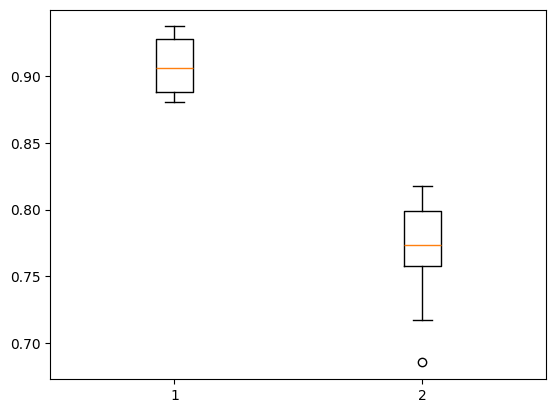

In [39]:
# Visualisasi hasil dengan boxplot
# Buat BoxPlotnya
import matplotlib.pyplot as plt
import numpy as np

Data = [scores_svm, scores_kNN]
L = ['SVM', 'kNN']

fig, ax = plt.subplots()

# Creating plot
plt.boxplot(Data)

# show plot
plt.show()

### Bagaimana jika ingin menggunakan word embedding sebagai representasi vektornya?

In [40]:
# Melakukan persiapan dokumen
# yang digunakan sebagai data adalah docs_nonzero
doc_gensim = [word_tokenize(d) for d in docs_nonzero]

In [42]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.4 MB/s eta 0:00:00


In [44]:
# membuat Word Embeddingnya
from gensim.models import FastText

N = len(doc_gensim)
dim = 300 # Jumlah neurons = ukuran vektor = jumlah kolom
model_FT = FastText(sentences=doc_gensim, vector_size=dim, window=5, min_count=1, workers=-1)

In [45]:
# NOTE:
# tidak dapat langsung menggunakan hasil dari word embedding
# representasi vektor embedding adalah representasi per kata
# harus mengkonversikan dari word embedding ke dalam vektor space
# dokumen x words
def we2vsm(model_we, data_we):
    N = len(data_we)
    L = model_we.vector_size
    vsm_we = np.empty([N, L], dtype=np.float64) # inisialisasi matriks
    for i,d in enumerate(data_we):
        tmp = np.zeros([1, L], dtype=np.float64)
        count = 0
        for t in d:
            try:
                tmp += model_we.wv.__getitem__([t])
                count += 1
            except:
                pass
        if count>0:
            vsm_we[i] = tmp/count
    return vsm_we

In [46]:
vsm_we = we2vsm(model_FT, doc_gensim)
vsm_we.shape

(1590, 300)

#### Setelah memiliki bentuk representasi dokumen, langkah selanjutnya adalah melakukan proses klasifikasi seperti yang telah dicontohkan sebelumnya

<h3 id="Latihan:"><font color="blue">Latihan 2:</font></h3>

- Lakukan klasifikasi dengan representasi yang telah diperoleh dari proses word embedding (vsm_we) dengan berbagai metode (knn, desicion tree, random forest, naive bayes, dan VSM)
- Visualisasikan hasilnya
- Bandingkan hasilnya dengan representasi dari VSM-TFIDF

Jawaban:

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

vsm_we = np.nan_to_num(vsm_we, nan=0.0, posinf=0.0, neginf=0.0)

idx = np.arange(len(Y))
idx_train, idx_test = train_test_split(
    idx,
    test_size=0.3,
    random_state=8989,
    stratify=Y
)

Xwe_train = vsm_we[idx_train]
Xwe_test  = vsm_we[idx_test]

Xtfidf_train = X_clear[idx_train]
Xtfidf_test  = X_clear[idx_test]

y_train = Y[idx_train]
y_test  = Y[idx_test]

print("Word Embedding train/test :", Xwe_train.shape, Xwe_test.shape)
print("TF-IDF train/test         :", Xtfidf_train.shape, Xtfidf_test.shape)
print("Label train/test          :", y_train.shape, y_test.shape)

Word Embedding train/test : (1113, 300) (477, 300)
TF-IDF train/test         : (1113, 10721) (477, 10721)
Label train/test          : (1113,) (477,)


In [58]:
# Definisikan model dan helper evaluasi

def build_models():
    return {
        "k-NN": KNeighborsClassifier(n_neighbors=8, weights="distance"),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),
        "Naive Bayes": GaussianNB(),
        "SVM": SVC(kernel="linear")
    }

def fit_predict_model(model, X_train, X_test, y_train):
    if isinstance(model, GaussianNB):
        if hasattr(X_train, "toarray"):
            X_train = X_train.toarray()
        if hasattr(X_test, "toarray"):
            X_test = X_test.toarray()

    start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    elapsed = time.time() - start
    return model, y_pred, elapsed

def evaluate_representation(X_train, X_test, y_train, y_test, repr_name):
    rows = []
    trained_models = {}
    predictions = {}

    for model_name, model in build_models().items():
        fitted_model, y_pred, elapsed = fit_predict_model(model, X_train, X_test, y_train)
        acc = accuracy_score(y_test, y_pred)

        rows.append({
            "Representasi": repr_name,
            "Metode": model_name,
            "Accuracy": acc,
            "Waktu (detik)": elapsed
        })

        trained_models[model_name] = fitted_model
        predictions[model_name] = y_pred

        print(f"{repr_name:15s} | {model_name:14s} | accuracy = {acc:.4f} | time = {elapsed:.2f}s")

    result_df = pd.DataFrame(rows)
    return result_df, trained_models, predictions

In [59]:
# Klasifikasi untuk Word Embedding dan TF-IDF

hasil_we, model_we, pred_we = evaluate_representation(
    Xwe_train, Xwe_test, y_train, y_test, "WordEmbedding"
)

hasil_tfidf, model_tfidf, pred_tfidf = evaluate_representation(
    Xtfidf_train, Xtfidf_test, y_train, y_test, "TF-IDF"
)

hasil_all = pd.concat([hasil_we, hasil_tfidf], ignore_index=True)
hasil_all = hasil_all.sort_values(["Metode", "Representasi"]).reset_index(drop=True)

display(hasil_all)

WordEmbedding   | k-NN           | accuracy = 0.5262 | time = 0.03s
WordEmbedding   | Decision Tree  | accuracy = 0.4444 | time = 0.49s
WordEmbedding   | Random Forest  | accuracy = 0.5828 | time = 3.05s
WordEmbedding   | Naive Bayes    | accuracy = 0.4486 | time = 0.01s
WordEmbedding   | SVM            | accuracy = 0.3627 | time = 0.27s
TF-IDF          | k-NN           | accuracy = 0.8239 | time = 0.05s
TF-IDF          | Decision Tree  | accuracy = 0.6436 | time = 0.45s
TF-IDF          | Random Forest  | accuracy = 0.8113 | time = 3.64s
TF-IDF          | Naive Bayes    | accuracy = 0.8679 | time = 0.37s
TF-IDF          | SVM            | accuracy = 0.9224 | time = 2.38s


,Representasi,Metode,Accuracy,Waktu (detik)
0,TF-IDF,Decision Tree,0.643606,0.450709
1,WordEmbedding,Decision Tree,0.444444,0.485580
2,TF-IDF,Naive Bayes,0.867925,0.370902
3,WordEmbedding,Naive Bayes,0.448637,0.008566
4,TF-IDF,Random Forest,0.811321,3.637266
5,WordEmbedding,Random Forest,0.582809,3.046014
6,TF-IDF,SVM,0.922432,2.384649
7,WordEmbedding,SVM,0.362683,0.272752
8,TF-IDF,k-NN,0.823899,0.047830
9,WordEmbedding,k-NN,0.526205,0.033478


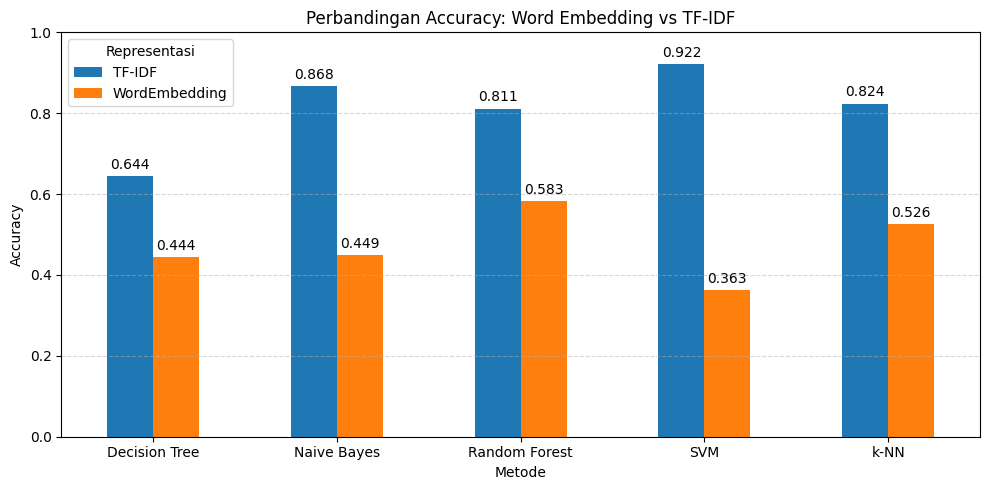

In [60]:
# Visualisasi perbandingan accuracy

pivot_acc = hasil_all.pivot(index="Metode", columns="Representasi", values="Accuracy")

ax = pivot_acc.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_title("Perbandingan Accuracy: Word Embedding vs TF-IDF")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Metode")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", linestyle="--", alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

In [61]:
# Best model dari masing - masing representasi

best_we_row = hasil_we.loc[hasil_we["Accuracy"].idxmax()]
best_tfidf_row = hasil_tfidf.loc[hasil_tfidf["Accuracy"].idxmax()]

print("Model terbaik Word Embedding:")
print(best_we_row)
print()

print("Model terbaik TF-IDF:")
print(best_tfidf_row)

Model terbaik Word Embedding:
Representasi     WordEmbedding
Metode           Random Forest
Accuracy              0.582809
Waktu (detik)         3.046014
Name: 2, dtype: object

Model terbaik TF-IDF:
Representasi       TF-IDF
Metode                SVM
Accuracy         0.922432
Waktu (detik)    2.384649
Name: 4, dtype: object


In [62]:
# Classification report untuk Word Embedding

for model_name, y_pred in pred_we.items():
    print("=" * 80)
    print(f"CLASSIFICATION REPORT - Word Embedding - {model_name}")
    print(classification_report(y_test, y_pred))

CLASSIFICATION REPORT - Word Embedding - k-NN
              precision    recall  f1-score   support

           0       0.69      0.30      0.42       169
           1       0.51      0.73      0.60       173
           2       0.48      0.55      0.51       135

    accuracy                           0.53       477
   macro avg       0.56      0.53      0.51       477
weighted avg       0.56      0.53      0.51       477

CLASSIFICATION REPORT - Word Embedding - Decision Tree
              precision    recall  f1-score   support

           0       0.43      0.53      0.47       169
           1       0.44      0.35      0.39       173
           2       0.47      0.46      0.47       135

    accuracy                           0.44       477
   macro avg       0.45      0.45      0.44       477
weighted avg       0.45      0.44      0.44       477

CLASSIFICATION REPORT - Word Embedding - Random Forest
              precision    recall  f1-score   support

           0       0.57    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [63]:
# Classification report untuk TF-IDF

for model_name, y_pred in pred_tfidf.items():
    print("=" * 80)
    print(f"CLASSIFICATION REPORT - TF-IDF - {model_name}")
    print(classification_report(y_test, y_pred))

CLASSIFICATION REPORT - TF-IDF - k-NN
              precision    recall  f1-score   support

           0       0.97      0.68      0.80       169
           1       0.90      0.87      0.88       173
           2       0.67      0.95      0.78       135

    accuracy                           0.82       477
   macro avg       0.85      0.83      0.82       477
weighted avg       0.86      0.82      0.83       477

CLASSIFICATION REPORT - TF-IDF - Decision Tree
              precision    recall  f1-score   support

           0       0.67      0.72      0.69       169
           1       0.63      0.61      0.62       173
           2       0.62      0.59      0.60       135

    accuracy                           0.64       477
   macro avg       0.64      0.64      0.64       477
weighted avg       0.64      0.64      0.64       477

CLASSIFICATION REPORT - TF-IDF - Random Forest
              precision    recall  f1-score   support

           0       0.71      0.92      0.80       1

<Figure size 1000x800 with 0 Axes>

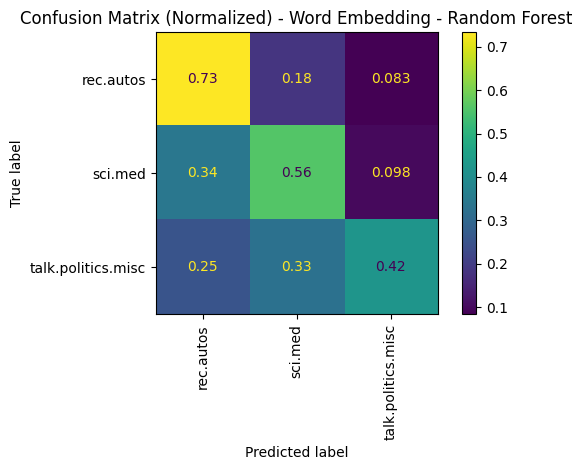

<Figure size 1000x800 with 0 Axes>

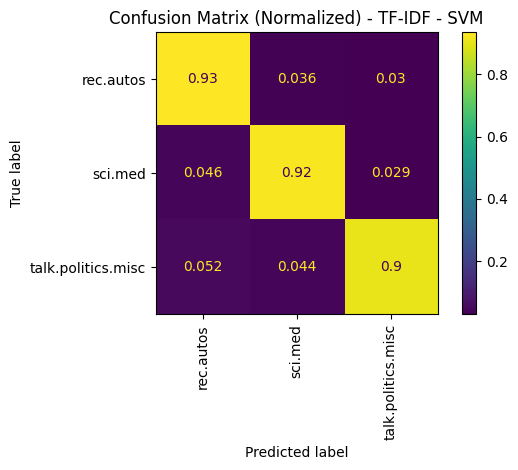

In [64]:
# Confusion matrix untuk model terbaik Word Embedding dan TF-IDF
best_we_name = best_we_row["Metode"]
best_tfidf_name = best_tfidf_row["Metode"]

target_names = data.target_names if hasattr(data, "target_names") else None

plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_we[best_we_name],
    display_labels=target_names,
    xticks_rotation="vertical",
    normalize="true"
)
plt.title(f"Confusion Matrix (Normalized) - Word Embedding - {best_we_name}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_tfidf[best_tfidf_name],
    display_labels=target_names,
    xticks_rotation="vertical",
    normalize="true"
)
plt.title(f"Confusion Matrix (Normalized) - TF-IDF - {best_tfidf_name}")
plt.tight_layout()
plt.show()

Kesimpulan:

Berdasarkan hasil eksperimen, representasi TF-IDF memberikan performa yang lebih baik dibandingkan representasi Word Embedding (vsm_we) pada seluruh metode klasifikasi yang diuji. Model terbaik diperoleh pada SVM dengan TF-IDF dengan accuracy 0.9224, sedangkan pada representasi Word Embedding model terbaik hanya mencapai sekitar 0.5828 pada Random Forest. Hal ini menunjukkan bahwa untuk dataset ini, representasi TF-IDF lebih mampu membedakan topik dokumen dibandingkan rata-rata word embedding. Selain itu, SVM memberikan hasil paling tinggi pada TF-IDF karena metode ini efektif untuk data berdimensi tinggi seperti fitur teks.